This project builds a binary classifier to distinguish normal network 
traffic from malicious attack traffic using the NSL-KDD dataset.
The goal is to demonstrate how machine learning can be applied to 
network security — a foundation for AI-powered intrusion detection systems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inside the notebook
%matplotlib inline

# Make plots look clean
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print("Libraries imported successfully")

Libraries imported successfully


Dfining column headers manually based on the official dataset documentation.
There are 41 network traffic features plus a label column and a 
difficulty score column.

In [2]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

print(f"Total columns defined: {len(columns)}")

Total columns defined: 43


In [3]:
# Load training and test sets
train = pd.read_csv('../data/KDDTrain+.txt', names=columns)
test  = pd.read_csv('../data/KDDTest+.txt',  names=columns)

print(f"Training set shape: {train.shape}")
print(f"Test set shape:     {test.shape}")

Training set shape: (125973, 43)
Test set shape:     (22544, 43)


In [4]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [6]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [7]:
train.isnull().sum().sum()

np.int64(0)

In [8]:
print("All traffic types in training set:")
print(train['label'].value_counts())

All traffic types in training set:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


The dataset includes a 'difficulty' column that rates how hard each 
record is to classify. This is metadata about the dataset itself, 
not a real network feature. We remove it before any analysis.\

In [9]:
train.drop('difficulty', axis=1, inplace=True)
test.drop('difficulty',  axis=1, inplace=True)

print(f"Training set shape after dropping difficulty: {train.shape}")
print(f"Test set shape after dropping difficulty:     {test.shape}")

Training set shape after dropping difficulty: (125973, 42)
Test set shape after dropping difficulty:     (22544, 42)


The original dataset contains many specific attack type labels.
For binary classification we simplify this into two classes:
- 0 = Normal traffic
- 1 = Attack traffic (any attack type)

In [10]:
train['label_binary'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['label_binary']  = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

print("Training set label distribution:")
print(train['label_binary'].value_counts())
print(f"\nAttack percentage: {train['label_binary'].mean()*100:.1f}%")

Training set label distribution:
label_binary
0    67343
1    58630
Name: count, dtype: int64

Attack percentage: 46.5%


Examine how balanced the dataset is between normal 
and attack traffic.

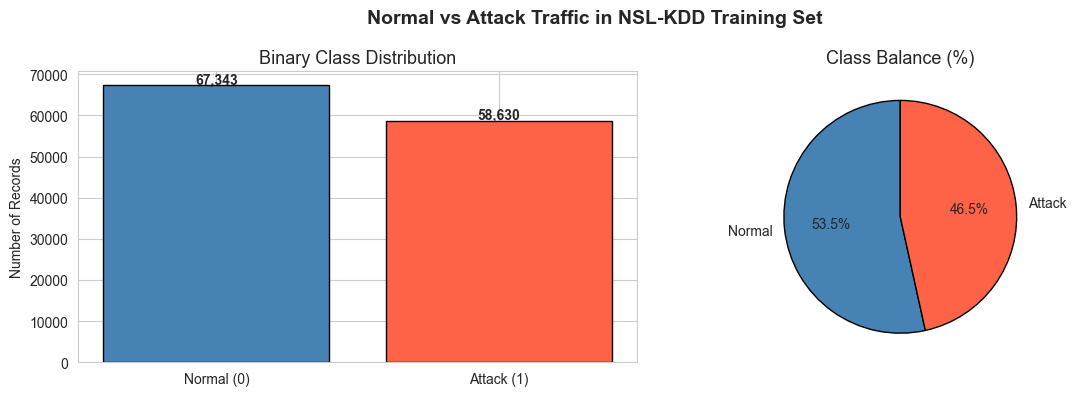

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot — counts
counts = train['label_binary'].value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], counts.values, 
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Binary Class Distribution', fontsize=13)
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Right plot — percentages
axes[1].pie(counts.values, labels=['Normal', 'Attack'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Balance (%)', fontsize=13)

plt.suptitle('Normal vs Attack Traffic in NSL-KDD Training Set', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Attack Type Breakdown

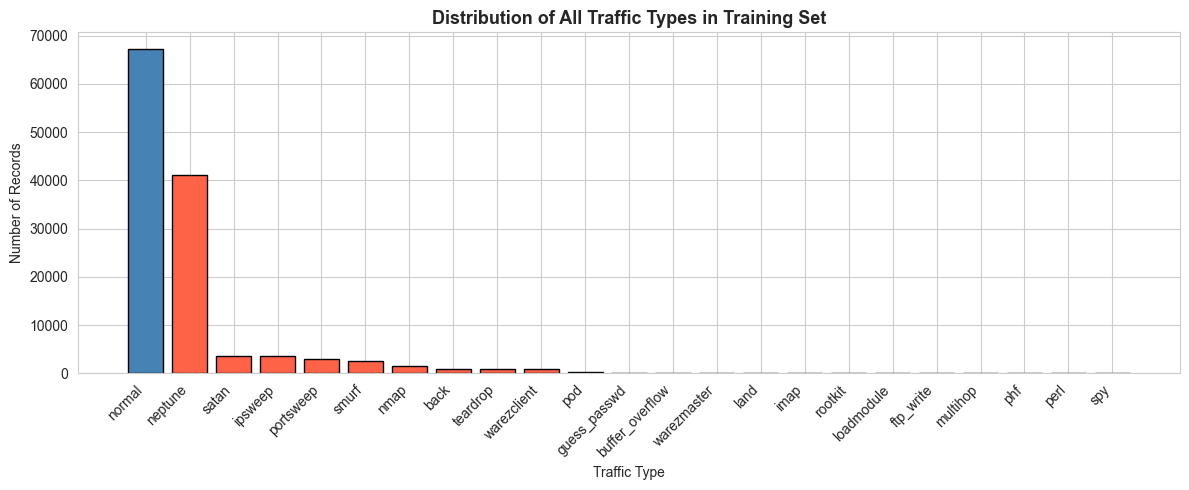


Record counts per type:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [12]:
# Count all traffic types
label_counts = train['label'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue' if x == 'normal' else 'tomato' 
          for x in label_counts.index]
bars = ax.bar(label_counts.index, label_counts.values, 
              color=colors, edgecolor='black')
ax.set_title('Distribution of All Traffic Types in Training Set', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Traffic Type')
ax.set_ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/attack_types.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRecord counts per type:")
print(label_counts)

neptune is by far the most common attack — 
it is a SYN flood DOS attack. normal traffic is the largest 
single category. Some attack types like `spy` and `phf` appear 
very rarely. 

Network connections use different protocols: TCP, UDP, and ICMP.
Examining whether certain protocols are associated more with 
attacks than normal traffic

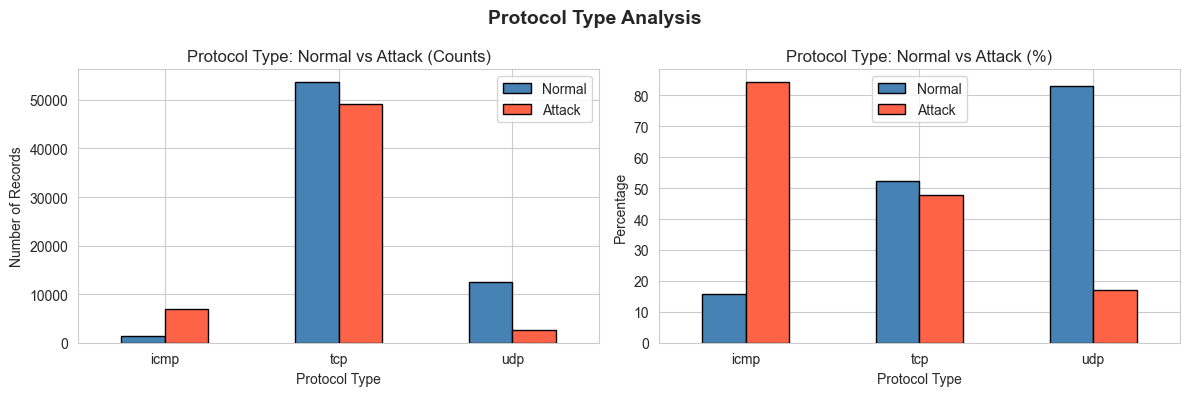

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left — raw counts
protocol_label = train.groupby(['protocol_type', 'label_binary']).size().unstack()
protocol_label.columns = ['Normal', 'Attack']
protocol_label.plot(kind='bar', ax=axes[0], 
                    color=['steelblue', 'tomato'],
                    edgecolor='black', rot=0)
axes[0].set_title('Protocol Type: Normal vs Attack (Counts)', fontsize=12)
axes[0].set_xlabel('Protocol Type')
axes[0].set_ylabel('Number of Records')
axes[0].legend()

# Right — proportions
protocol_pct = protocol_label.div(protocol_label.sum(axis=1), axis=0) * 100
protocol_pct.plot(kind='bar', ax=axes[1],
                  color=['steelblue', 'tomato'],
                  edgecolor='black', rot=0)
axes[1].set_title('Protocol Type: Normal vs Attack (%)', fontsize=12)
axes[1].set_xlabel('Protocol Type')
axes[1].set_ylabel('Percentage')
axes[1].legend()

plt.suptitle('Protocol Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/protocol_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

ICMP traffic is almost entirely composed of attacks.
This makes intuitive sense — ICMP
is commonly exploited in network scanning and 
flood attacks. UDP also shows a high attack proportion. 
TCP, being the most common protocol for legitimate web traffic, 
has a higher proportion of normal connections.

Data Transfer Patterns

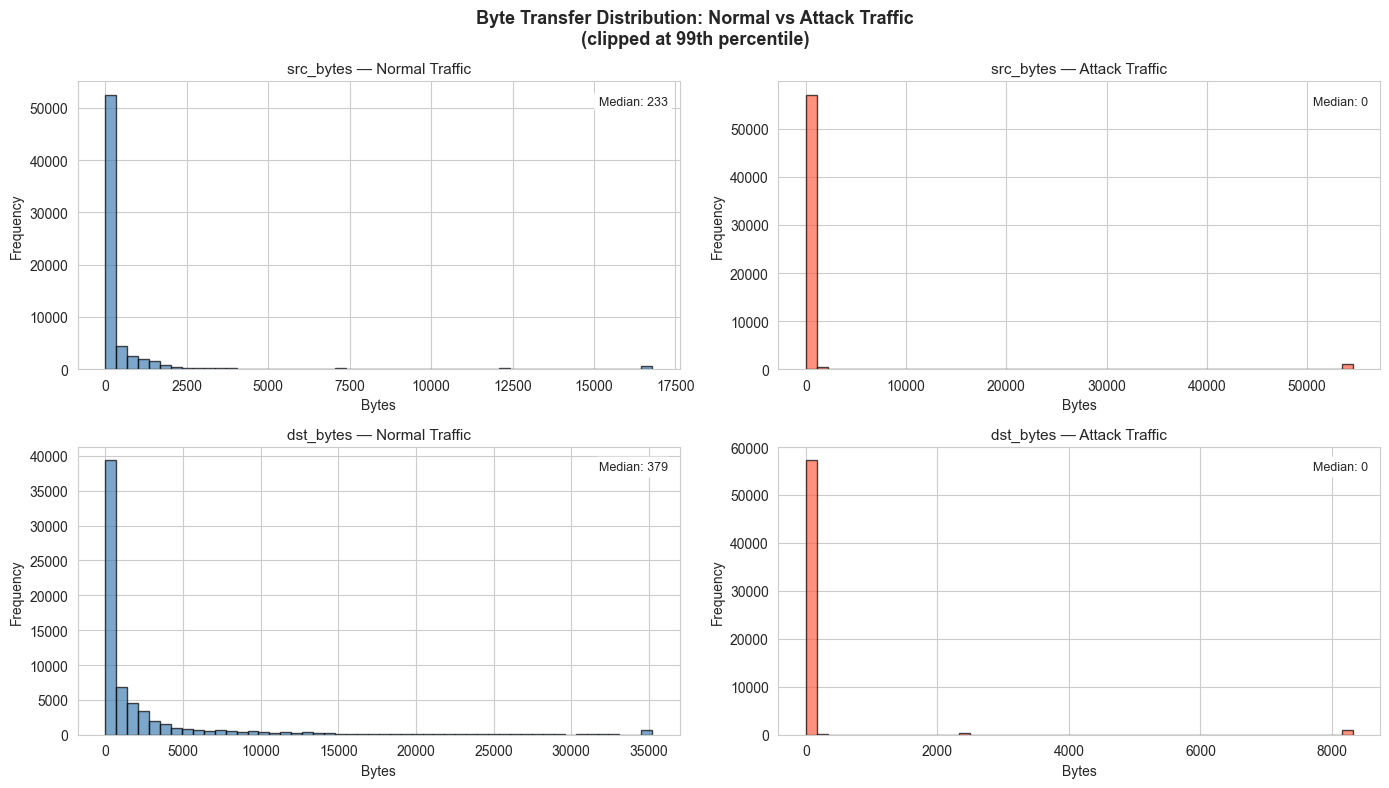

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, col in enumerate(['src_bytes', 'dst_bytes']):
    for label_val, label_name, ax in [
        (0, 'Normal', axes[idx][0]),
        (1, 'Attack', axes[idx][1])
    ]:
        subset = train[train['label_binary'] == label_val][col]
        # Clip extreme values so the plot is readable
        subset.clip(upper=subset.quantile(0.99)).hist(
            bins=50, ax=ax, 
            color='steelblue' if label_val == 0 else 'tomato',
            edgecolor='black', alpha=0.7
        )
        ax.set_title(f'{col} — {label_name} Traffic', fontsize=11)
        ax.set_xlabel('Bytes')
        ax.set_ylabel('Frequency')
        ax.text(0.98, 0.95, f'Median: {subset.median():.0f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, bbox=dict(boxstyle='round', facecolor='white'))

plt.suptitle('Byte Transfer Distribution: Normal vs Attack Traffic\n(clipped at 99th percentile)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/byte_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

Attack traffic shows very different byte transfer 
patterns compared to normal traffic. Many attack connections 
transfer almost no data (scanning probes) while others transfer 
extremely large amounts (DoS floods). Normal traffic tends to 
show more moderate, consistent patterns typical of web browsing, 

Feature Correlation Heatmap

Top 10 features most correlated with attack label:
same_srv_rate               0.751913
dst_host_srv_count          0.722535
dst_host_same_srv_rate      0.693803
logged_in                   0.690171
dst_host_srv_serror_rate    0.654985
dst_host_serror_rate        0.651842
serror_rate                 0.650652
srv_serror_rate             0.648289
count                       0.576444
dst_host_count              0.375052
Name: label_binary, dtype: float64


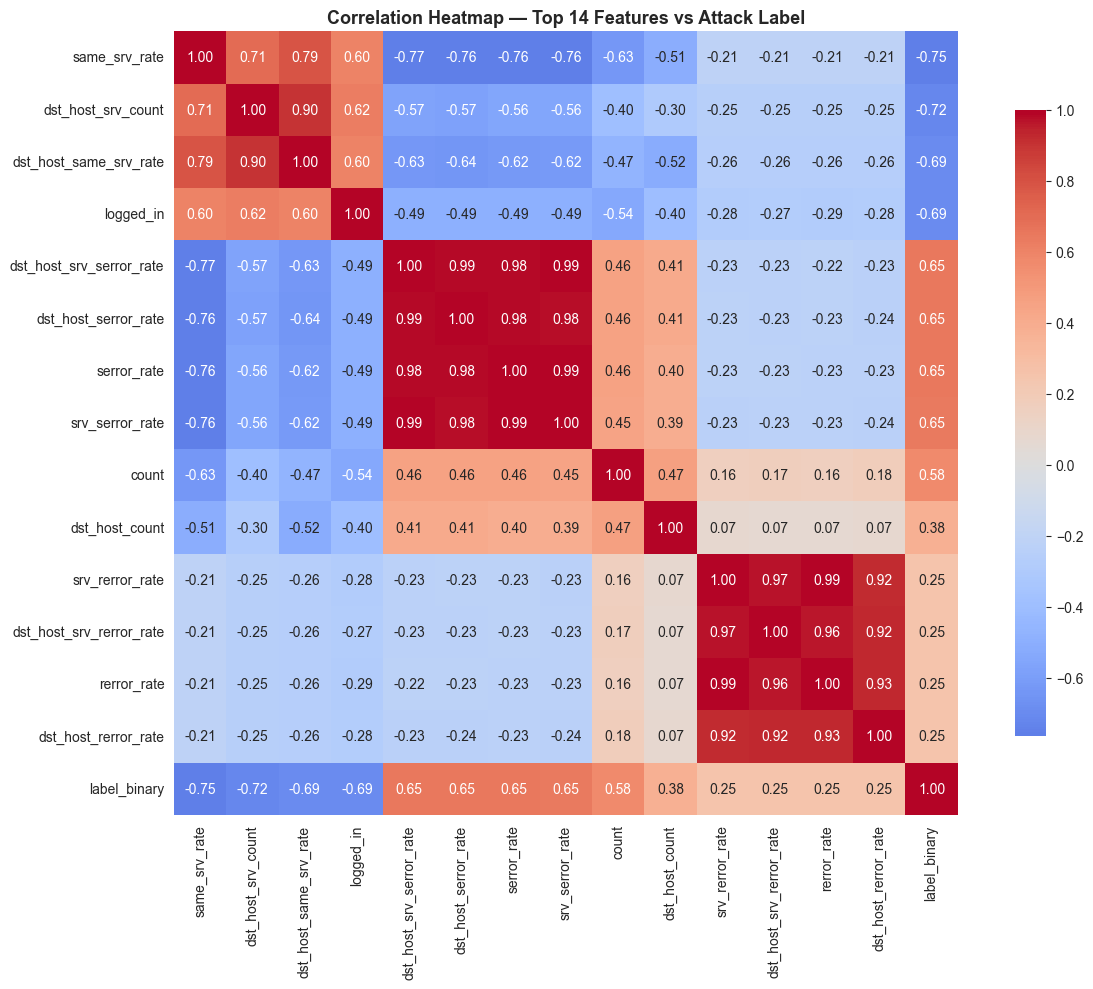

In [15]:
# Select numeric columns only for correlation
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Remove label_binary from features but keep it for reference
corr_matrix = train[numeric_cols].corr()

# Find top features correlated with the label
label_corr = corr_matrix['label_binary'].drop('label_binary').abs().sort_values(ascending=False)
print("Top 10 features most correlated with attack label:")
print(label_corr.head(10))

# Plot heatmap of top 15 most correlated features for readability
top_features = label_corr.head(14).index.tolist() + ['label_binary']

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(train[top_features].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Top 14 Features vs Attack Label', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Several features show strong correlation with 
the attack label, particularly `serror_rate`, `dst_host_serror_rate`, 
and `srv_serror_rate` — these measure the rate of SYN errors, 
which spike during SYN flood attacks like neptune. 
Some feature pairs are also highly correlated with each other,
suggesting redundancy. The Random Forest model we build later 
will naturally handle this by selecting the most informative 
features at each split.

Error Rate Features: The Clearest Signal

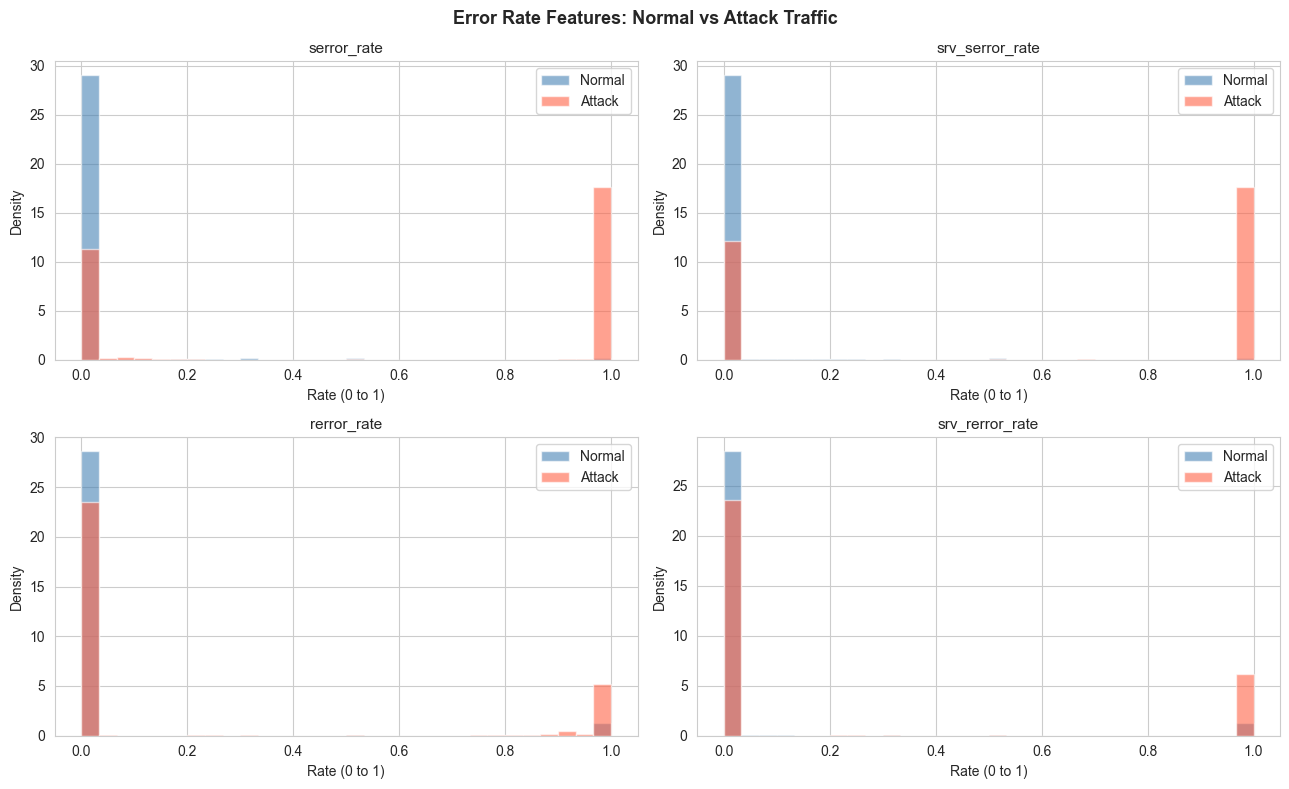

In [16]:
error_features = ['serror_rate', 'srv_serror_rate', 
                  'rerror_rate', 'srv_rerror_rate']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, feature in enumerate(error_features):
    normal_vals  = train[train['label_binary'] == 0][feature]
    attack_vals  = train[train['label_binary'] == 1][feature]
    
    axes[i].hist(normal_vals, bins=30, alpha=0.6, 
                 color='steelblue', label='Normal', density=True)
    axes[i].hist(attack_vals, bins=30, alpha=0.6, 
                 color='tomato', label='Attack', density=True)
    axes[i].set_title(f'{feature}', fontsize=11)
    axes[i].set_xlabel('Rate (0 to 1)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Error Rate Features: Normal vs Attack Traffic', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/error_rates.png', dpi=150, bbox_inches='tight')
plt.show()

The separation between normal and attack traffic 
in these error rate features is dramatic. Normal connections 
cluster almost entirely at 0 (no errors), while attack connections 
spread across the full range with many showing error rates near 1.0.
This tells us these features will likely be among the most important 
for our classifier — a finding we will confirm in the feature 
importance analysis on Day 4.

Key findings from our exploratory analysis:

1. The dataset is well-balanced between normal and attack traffic,
   making our accuracy metrics reliable and meaningful.

2. ICMP protocol is almost exclusively associated with attacks,
   particularly network scanning and flood-based DoS attacks.

3. Error rate features (serror_rate, rerror_rate) show the 
   strongest visual separation between normal and attack traffic
   and will likely dominate feature importance rankings.

4. Byte transfer patterns differ significantly — attack traffic 
   tends toward extremes (near-zero for probes, very high for floods)
   while normal traffic is more moderate.

5. Some features are highly correlated with each other, suggesting
   redundancy that ensemble methods like Random Forest handle well
   through feature selection at each split.

In [18]:
print("Categorical columns:")
print(train.select_dtypes(include='str').columns.tolist())
print()
print("Unique values per categorical column:")
for col in train.select_dtypes(include='str').columns:
    print(f"  {col}: {train[col].nunique()} unique values")

Categorical columns:
['protocol_type', 'service', 'flag', 'label']

Unique values per categorical column:
  protocol_type: 3 unique values
  service: 70 unique values
  flag: 11 unique values
  label: 23 unique values


Three columns contain text values that must be converted to numbers
before feeding into the model:
- protocol_type: the network protocol (tcp, udp, icmp)
- service: the network service (http, ftp, smtp, etc.)
- flag: the status of the connection (SF, REJ, S0, etc.)

In [25]:
from sklearn.preprocessing import LabelEncoder

# make copies
train_processed = train.copy()
test_processed  = test.copy()

categorical_cols = ['protocol_type', 'service', 'flag']

encoders = {}  # Store each encoder

for col in categorical_cols:
    le = LabelEncoder()
    
    # Fit only on training data
    le.fit(train_processed[col])
    
    # Get the known categories
    known_categories = set(le.classes_)
    
    # Check if test set has values not seen in training
    test_categories  = set(test_processed[col].unique())
    unseen = test_categories - known_categories
    
    if unseen:
        print(f"  '{col}' has {len(unseen)} unseen value(s) in test set: {unseen}")
        # replace unseen values with the most common training value
        most_common = train_processed[col].mode()[0]
        test_processed[col] = test_processed[col].apply(
            lambda x: x if x in known_categories else most_common
        )
    else:
        print(f"  '{col}': no unseen values — safe to encode directly")
    
    # Now encode both sets
    train_processed[col] = le.transform(train_processed[col])
    test_processed[col]  = le.transform(test_processed[col])
    
    encoders[col] = le  # save the encoder

print("\nEncoding complete.")

  'protocol_type': no unseen values — safe to encode directly
  'service': no unseen values — safe to encode directly
  'flag': no unseen values — safe to encode directly

Encoding complete.


The "service" column contains network service types that appear in real test traffic but were absent from training data. We explicitly detect and handle these unseen values by replacing them with the most common training value.

In [21]:
print("Sample of encoded columns (first 5 rows):")
print(train_processed[categorical_cols].head())
print()
print("Data types after encoding:")
print(train_processed[categorical_cols].dtypes)

Sample of encoded columns (first 5 rows):
   protocol_type  service  flag
0              1       20     9
1              2       44     9
2              1       49     5
3              1       24     9
4              1       24     9

Data types after encoding:
protocol_type    int64
service          int64
flag             int64
dtype: object


We now separate our data into:
- X: the input features (everything the model learns from)
- y: the target label (what the model is trying to predict)

Droping the original text `label`

In [22]:
# Define which columns are features
# Drop both label columns — one is text, one is our target
feature_cols = [col for col in train_processed.columns 
                if col not in ['label', 'label_binary']]

print(f"Number of features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")

# Create X and y for training and test
X_train = train_processed[feature_cols]
y_train = train_processed['label_binary']

X_test  = test_processed[feature_cols]
y_test  = test_processed['label_binary']

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Number of features: 41
Feature columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

X_train shape: (125973, 41)
X_test shape:  (22544, 41)
y_train shape: (125973,)
y_test shape:  (22544,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only — this is non-negotiable
X_train_scaled = scaler.fit_transform(X_train)
# apply the same transformation to test data
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames so column names are preserved
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print("Before scaling — src_bytes stats:")
print(X_train['src_bytes'].describe())
print("\nAfter scaling — src_bytes stats:")
print(X_train_scaled['src_bytes'].describe())

Before scaling — src_bytes stats:
count    1.259730e+05
mean     4.556674e+04
std      5.870331e+06
min      0.000000e+00
25%      0.000000e+00
50%      4.400000e+01
75%      2.760000e+02
max      1.379964e+09
Name: src_bytes, dtype: float64

After scaling — src_bytes stats:
count    1.259730e+05
mean     5.640437e-19
std      1.000004e+00
min     -7.762241e-03
25%     -7.762241e-03
50%     -7.754745e-03
75%     -7.715224e-03
max      2.350675e+02
Name: src_bytes, dtype: float64


Preprocessing Summary Check

In [27]:
print("=== Final Preprocessing Check ===")
print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")
print(f"y_train shape        : {y_train.shape}")
print(f"y_test shape         : {y_test.shape}")

print(f"\nAny nulls in X_train : {X_train_scaled.isnull().sum().sum()}")
print(f"Any nulls in X_test  : {X_test_scaled.isnull().sum().sum()}")

print(f"\ny_train class balance:")
print(y_train.value_counts())
print(f"\ny_test class balance:")
print(y_test.value_counts())

=== Final Preprocessing Check ===

X_train_scaled shape : (125973, 41)
X_test_scaled shape  : (22544, 41)
y_train shape        : (125973,)
y_test shape         : (22544,)

Any nulls in X_train : 0
Any nulls in X_test  : 0

y_train class balance:
label_binary
0    67343
1    58630
Name: count, dtype: int64

y_test class balance:
label_binary
1    12833
0     9711
Name: count, dtype: int64
